**Prática de Histogramas**

1) 
- Produza a imagem ‘negativa’ do arquivo ‘im_cells.png’
- Com a imagem negativa, produza a imagem original novamente. 
- Mostre lado a lado a imagem original e a negativa. Em qual deles os objetos presentes na imagem são melhor percebidos? Justifique.
- Aplique a imagem uma função logarítmica.

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


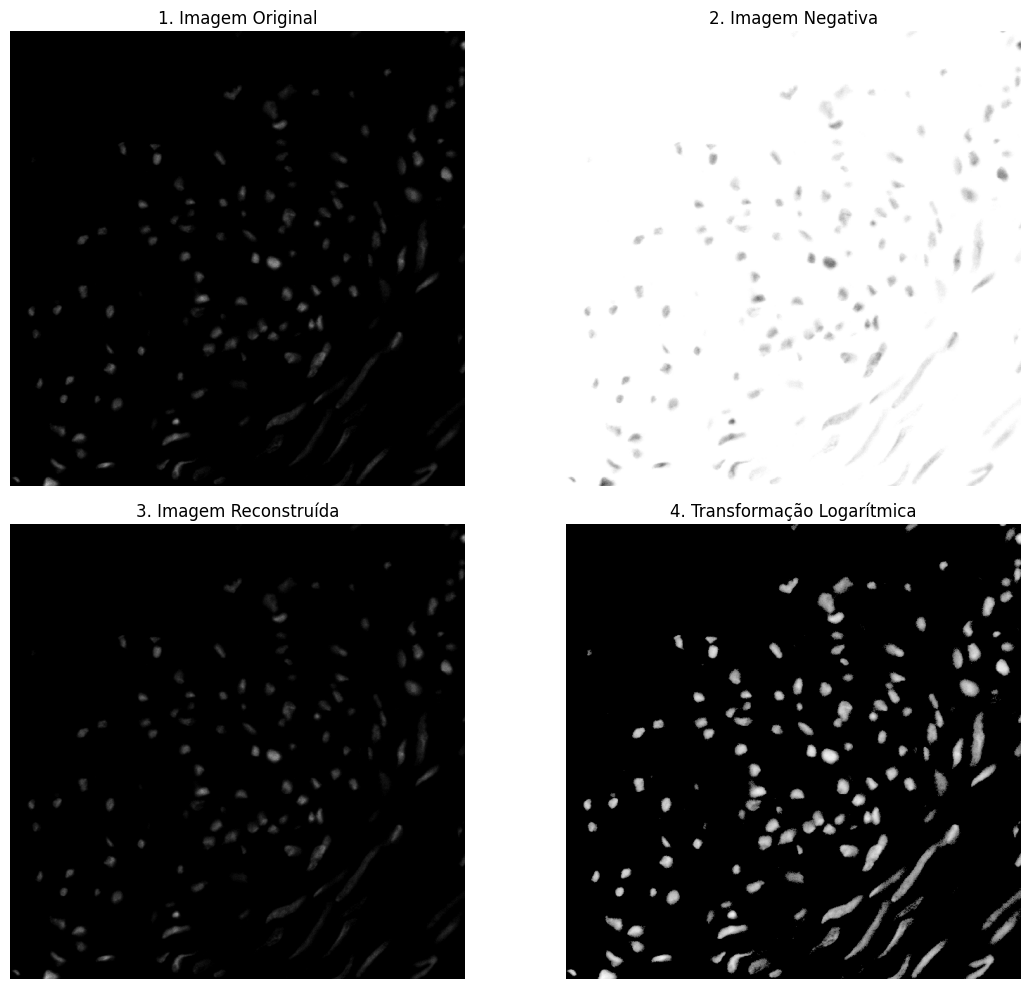

In [1]:
%pip install opencv-python numpy matplotlib
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar a imagem em tons de cinza
imagem_original = cv2.imread('im_cells.png', cv2.IMREAD_GRAYSCALE)

# 2. Produzir a imagem negativa
imagem_negativa = 255 - imagem_original

# 3. Reconstruir a imagem original a partir da negativa
imagem_reconstruida = 255 - imagem_negativa

# 4. Aplicar a transformação logarítmica
# Constante de escala c escolhida para mapear o valor máximo para 255
c = 255 / np.log(1 + np.max(imagem_original))
imagem_logaritmica = (c * np.log(1 + imagem_original)).astype(np.uint8)

# 5. Plotar os resultados em um grid 2x2
fig, eixos = plt.subplots(2, 2, figsize=(12, 10))

# Imagem original
eixos[0, 0].imshow(imagem_original, cmap='gray', vmin=0, vmax=255)
eixos[0, 0].set_title('1. Imagem Original')
eixos[0, 0].axis('off')

# Imagem negativa
eixos[0, 1].imshow(imagem_negativa, cmap='gray', vmin=0, vmax=255)
eixos[0, 1].set_title('2. Imagem Negativa')
eixos[0, 1].axis('off')

# Imagem reconstruída
eixos[1, 0].imshow(imagem_reconstruida, cmap='gray', vmin=0, vmax=255)
eixos[1, 0].set_title('3. Imagem Reconstruída')
eixos[1, 0].axis('off')

# Imagem logarítmica
eixos[1, 1].imshow(imagem_logaritmica, cmap='gray', vmin=0, vmax=255)
eixos[1, 1].set_title('4. Transformação Logarítmica')
eixos[1, 1].axis('off')

plt.tight_layout()
plt.show()

### Discussão da Percepção Visual (Questão 1)

Os objetos presentes na imagem (células) são melhor percebidos na **imagem negativa**. Para mim o contraste de ter o fundo branco e os bjetos escuros facilita na visualização.

2)
- Abra a imagem 'pout.tif' e mostre seu histograma.
- Equalize a imagem anterior e mostre novamente seu histograma. Mostra a curva de transformação (consulte https://www.mathworks.com/help/images/histogram-equalization.html)
(procurar função OpenCV)

C:\Users\muril\AppData\Local\Temp\ipykernel_29908\2723223053.py:22: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  eixos[0, 1].hist(imagem_pout.flatten(), 256, [0, 256], color='gray')
C:\Users\muril\AppData\Local\Temp\ipykernel_29908\2723223053.py:41: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  eixos[1, 1].hist(imagem_equalizada.flatten(), 256, [0, 256], color='gray')


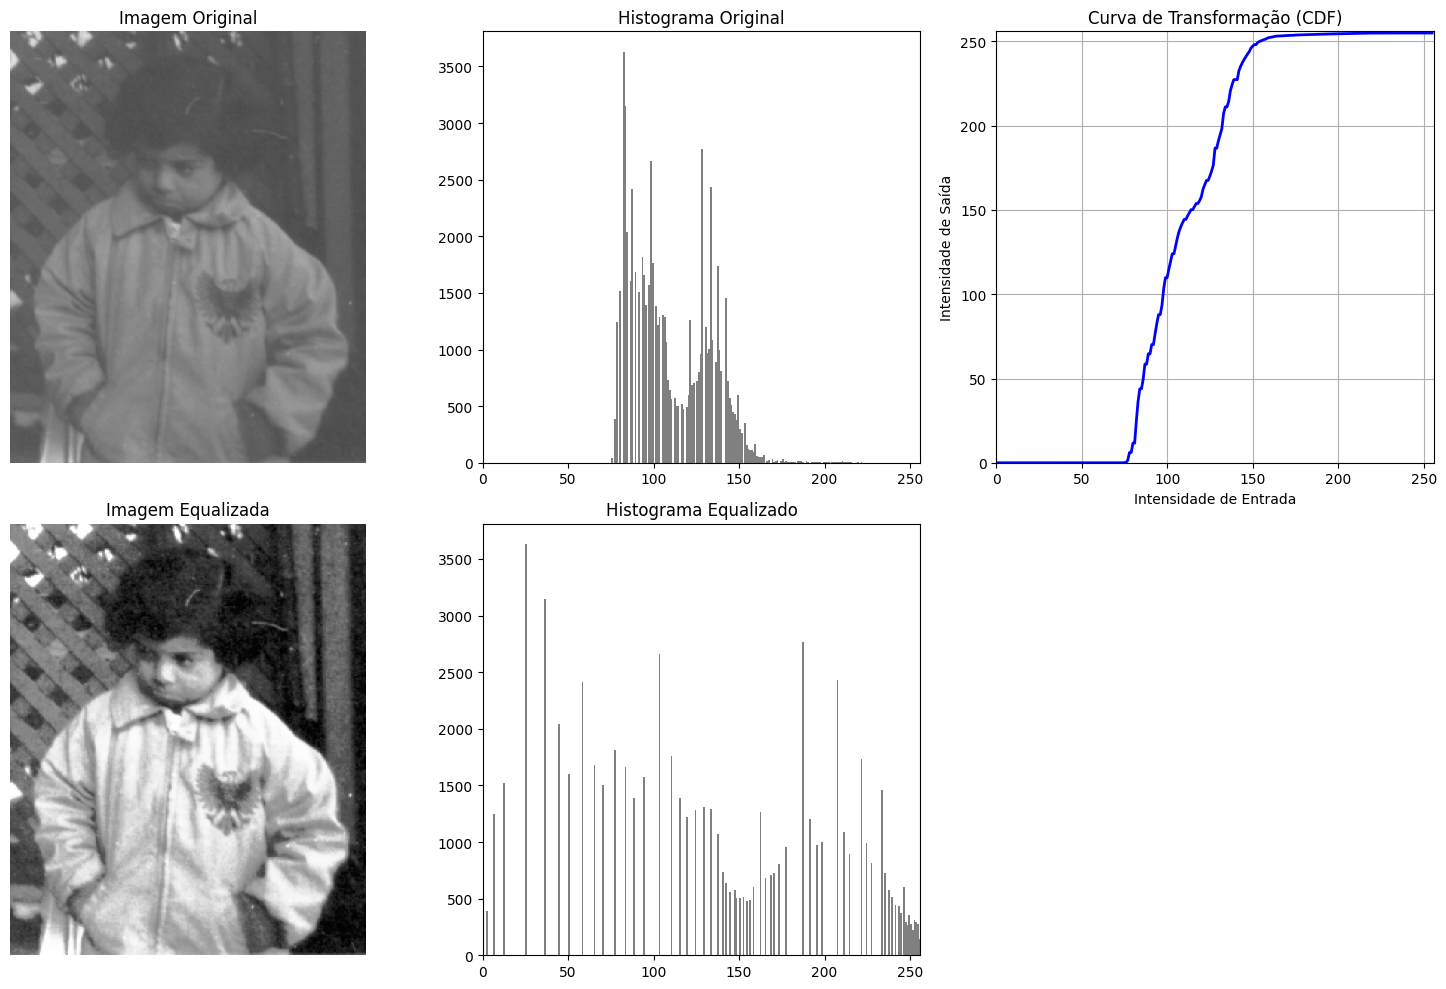

In [2]:
# 1. Carregar a imagem pout.tif em tons de cinza
imagem_pout = cv2.imread('pout.tif', cv2.IMREAD_GRAYSCALE)

# 2. Equalizar a imagem usando a função do OpenCV
imagem_equalizada = cv2.equalizeHist(imagem_pout)

# 3. Calcular a curva de transformação (CDF acumulada e normalizada)
histograma, bins = np.histogram(imagem_pout.flatten(), 256, [0, 256])
cdf = histograma.cumsum()
# Normaliza a curva para mapear de 0 a 255
curva_transformacao = cdf * 255 / cdf.max()

# 4. Mostrar os resultados em subplots
fig, eixos = plt.subplots(2, 3, figsize=(15, 10))

# Imagem original
eixos[0, 0].imshow(imagem_pout, cmap='gray', vmin=0, vmax=255)
eixos[0, 0].set_title('Imagem Original')
eixos[0, 0].axis('off')

# Histograma original
eixos[0, 1].hist(imagem_pout.flatten(), 256, [0, 256], color='gray')
eixos[0, 1].set_title('Histograma Original')
eixos[0, 1].set_xlim([0, 256])

# Curva de transformação
eixos[0, 2].plot(curva_transformacao, color='blue', linewidth=2)
eixos[0, 2].set_title('Curva de Transformação (CDF)')
eixos[0, 2].set_xlabel('Intensidade de Entrada')
eixos[0, 2].set_ylabel('Intensidade de Saída')
eixos[0, 2].set_xlim([0, 256])
eixos[0, 2].set_ylim([0, 256])
eixos[0, 2].grid(True)

# Imagem equalizada
eixos[1, 0].imshow(imagem_equalizada, cmap='gray', vmin=0, vmax=255)
eixos[1, 0].set_title('Imagem Equalizada')
eixos[1, 0].axis('off')

# Histograma equalizado
eixos[1, 1].hist(imagem_equalizada.flatten(), 256, [0, 256], color='gray')
eixos[1, 1].set_title('Histograma Equalizado')
eixos[1, 1].set_xlim([0, 256])

# Remover o último eixo vazio
fig.delaxes(eixos[1, 2])

plt.tight_layout()
plt.show()

3) *Implemente* o algoritmo de equalização de histograma e aplique a imagem ‘imcells.png’. Use o mínimos de laços for - tente realizar operações diretas com matrizes e vetores do numpy
- Aplique o mesmo algortimo 2x na mesma imagem e compare os resultados

Diferença máxima absoluta entre a 1ª e a 2ª equalização: 0
As imagens da 1ª e 2ª equalizações são idênticas? Sim


C:\Users\muril\AppData\Local\Temp\ipykernel_29908\417826180.py:55: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  eixos[1, 0].hist(imagem_celulas.flatten(), 256, [0, 256], color='gray')
C:\Users\muril\AppData\Local\Temp\ipykernel_29908\417826180.py:59: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  eixos[1, 1].hist(imagem_eq1.flatten(), 256, [0, 256], color='gray')
C:\Users\muril\AppData\Local\Temp\ipykernel_29908\417826180.py:63: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  eixos[1, 2].hist(imagem_eq2.flatten(), 256, [0, 256], color='gray')


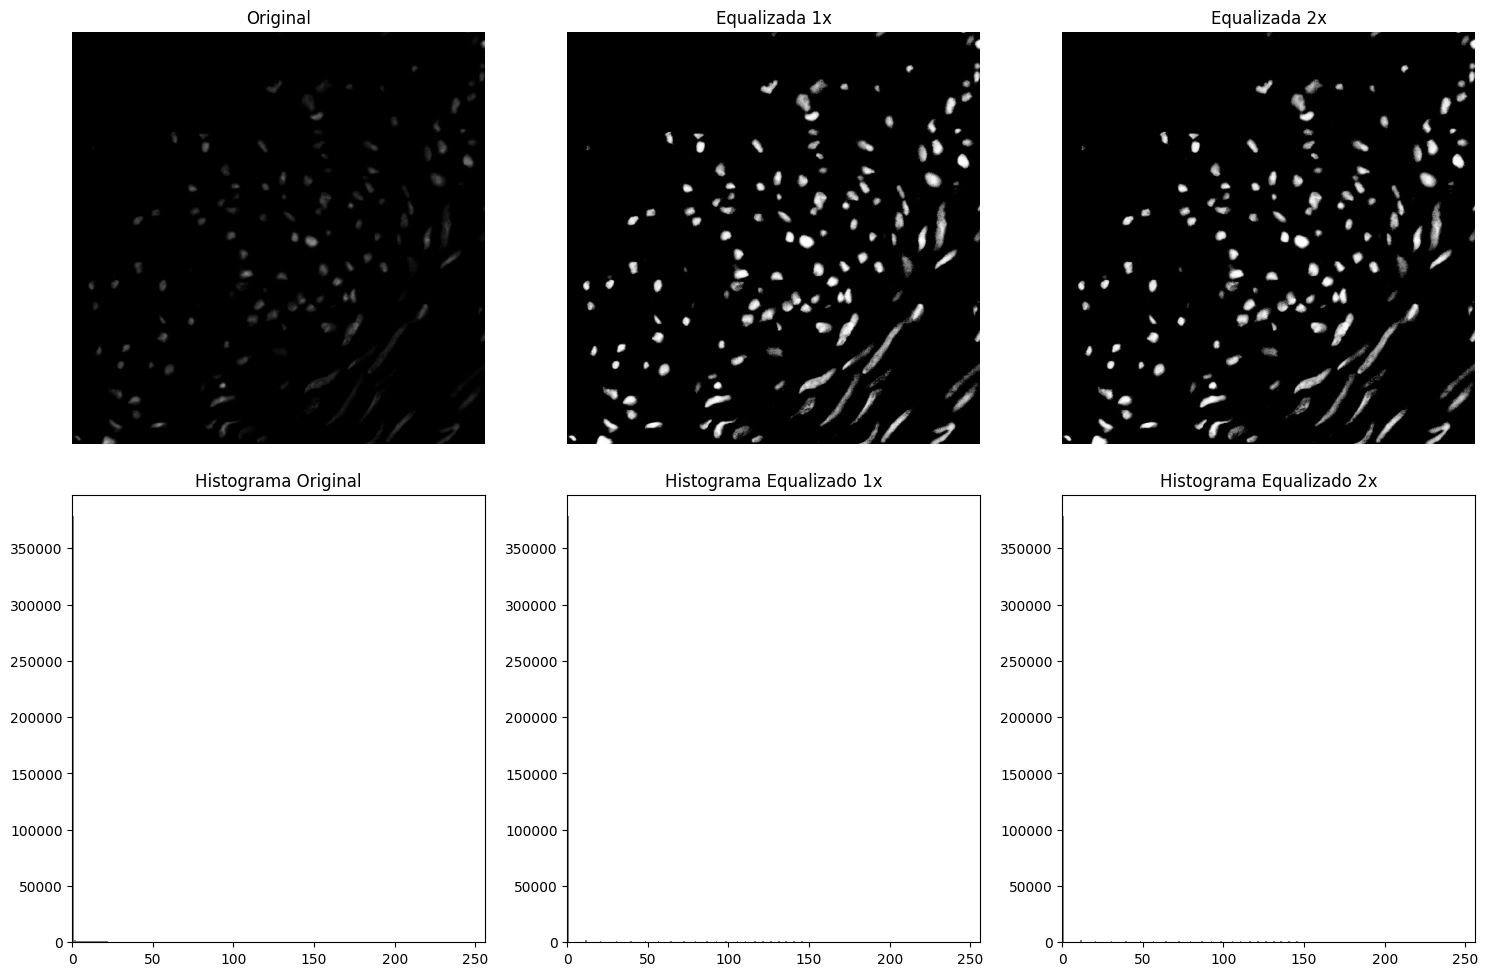

In [ ]:
# 1. Carregar a imagem im_cells.png em tons de cinza
imagem_celulas = cv2.imread('im_cells.png', cv2.IMREAD_GRAYSCALE)

def equalizar_histograma_numpy(imagem):
    # Calcula histograma
    hist, bins = np.histogram(imagem.flatten(), 256, [0, 256])
    # Calcula a CDF (soma acumulada)
    cdf = hist.cumsum()
    # Ignora valores nulos para encontrar o mínimo não-zero
    cdf_minimo = cdf[cdf > 0].min()
    # Mapeamento linear para a faixa [0, 255]
    numerador = cdf - cdf_minimo
    denominador = cdf.max() - cdf_minimo
    
    if denominador == 0:
        cdf_mapeada = np.zeros_like(cdf)
    else:
        cdf_mapeada = np.round((numerador / denominador) * 255).astype(np.uint8)
        
    # Mapear os pixels usando indexação direta no numpy (lookup table)
    imagem_equalizada = cdf_mapeada[imagem]
    return imagem_equalizada

# 3. Aplicar equalização pela primeira vez
imagem_eq1 = equalizar_histograma_numpy(imagem_celulas)

# 4. Aplicar equalização pela segunda vez
imagem_eq2 = equalizar_histograma_numpy(imagem_eq1)

# 5. Comparar os resultados de eq1 e eq2
diferenca_maxima = np.max(np.abs(imagem_eq1.astype(int) - imagem_eq2.astype(int)))
sao_identicas = np.array_equal(imagem_eq1, imagem_eq2)

print(f"Diferença máxima absoluta entre a 1ª e a 2ª equalização: {diferenca_maxima}")
print(f"As imagens da 1ª e 2ª equalizações são idênticas? {'Sim' if sao_identicas else 'Não'}")

# 6. Mostrar imagens e histogramas
fig, eixos = plt.subplots(2, 3, figsize=(15, 10))

# Imagens
eixos[0, 0].imshow(imagem_celulas, cmap='gray', vmin=0, vmax=255)
eixos[0, 0].set_title('Original')
eixos[0, 0].axis('off')

eixos[0, 1].imshow(imagem_eq1, cmap='gray', vmin=0, vmax=255)
eixos[0, 1].set_title('Equalizada 1x')
eixos[0, 1].axis('off')

eixos[0, 2].imshow(imagem_eq2, cmap='gray', vmin=0, vmax=255)
eixos[0, 2].set_title('Equalizada 2x')
eixos[0, 2].axis('off')

# Histogramas
eixos[1, 0].hist(imagem_celulas.flatten(), 256, [0, 256], color='gray')
eixos[1, 0].set_title('Histograma Original')
eixos[1, 0].set_xlim([0, 256])

eixos[1, 1].hist(imagem_eq1.flatten(), 256, [0, 256], color='gray')
eixos[1, 1].set_title('Histograma Equalizado 1x')
eixos[1, 1].set_xlim([0, 256])

eixos[1, 2].hist(imagem_eq2.flatten(), 256, [0, 256], color='gray')
eixos[1, 2].set_title('Histograma Equalizado 2x')
eixos[1, 2].set_xlim([0, 256])

plt.tight_layout()
plt.show()